# Lec06 시계열

In [1]:
import pandas as pd

## Data loading

In [19]:
df = pd.read_csv('./dataset/AirPassengers.csv', parse_dates=['Month'])

In [20]:
df.head()

,Month,#Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [22]:
df.columns = ['rdate', 'cnt']
df['rdate'] =  pd.to_datetime(df["rdate"]).dt.to_period('M')
df.head()

,rdate,cnt
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype    
---  ------  --------------  -----    
 0   rdate   144 non-null    period[M]
 1   cnt     144 non-null    int64    
dtypes: int64(1), period[M](1)
memory usage: 2.4 KB


## EDA

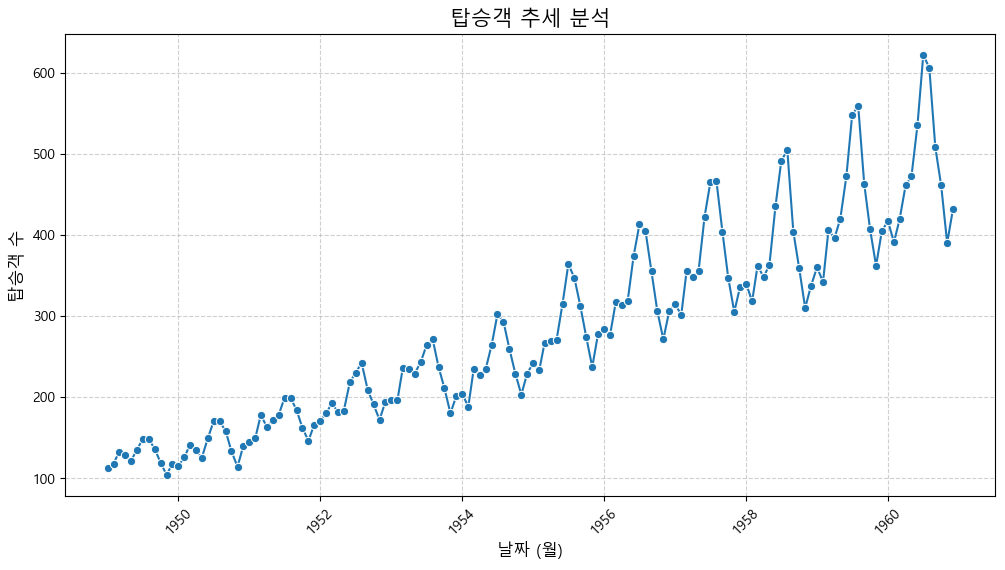

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

if df['rdate'].dtype == 'period[M]':
    df['rdate_plot'] = df['rdate'].dt.to_timestamp()
else:
    df['rdate_plot'] = df['rdate']

# 한글 깨짐 방지 설정 (필요 시)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.figure(figsize=(12, 6))

sns.lineplot(data=df, x='rdate_plot', y='cnt', marker='o') 

plt.title('탑승객 추세 분석', fontsize=15)
plt.xlabel('날짜 (월)', fontsize=12)
plt.ylabel('탑승객 수', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45) # 라벨이 겹치지 않도록 회전
plt.show()

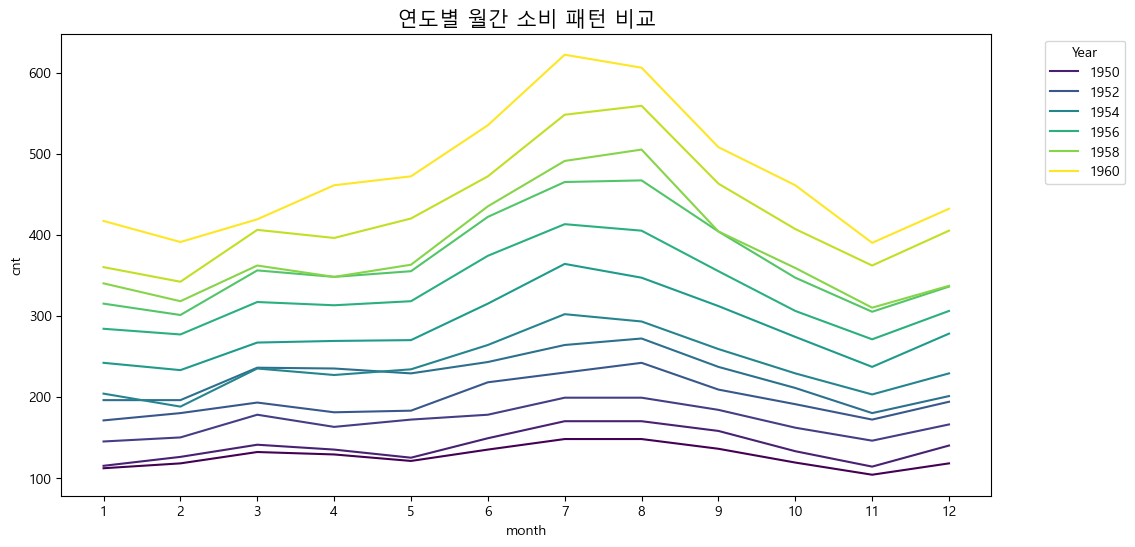

In [30]:
# 월(month)과 연도(year) 컬럼이 있다고 가정
df['year'] = pd.to_datetime(df['rdate_plot']).dt.year
df['month'] = pd.to_datetime(df['rdate_plot']).dt.month

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='month', y='cnt', hue='year', palette='viridis')

plt.title('연도별 월간 소비 패턴 비교', fontsize=15)
plt.xticks(range(1, 13)) # 1월부터 12월까지 표시
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [31]:
df['rdate'].min(), df['rdate'].max()

(Period('1949-01', 'M'), Period('1960-12', 'M'))

C:\Users\user\AppData\Local\Temp\ipykernel_19756\2068795273.py:30: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\IT\workspace_python\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


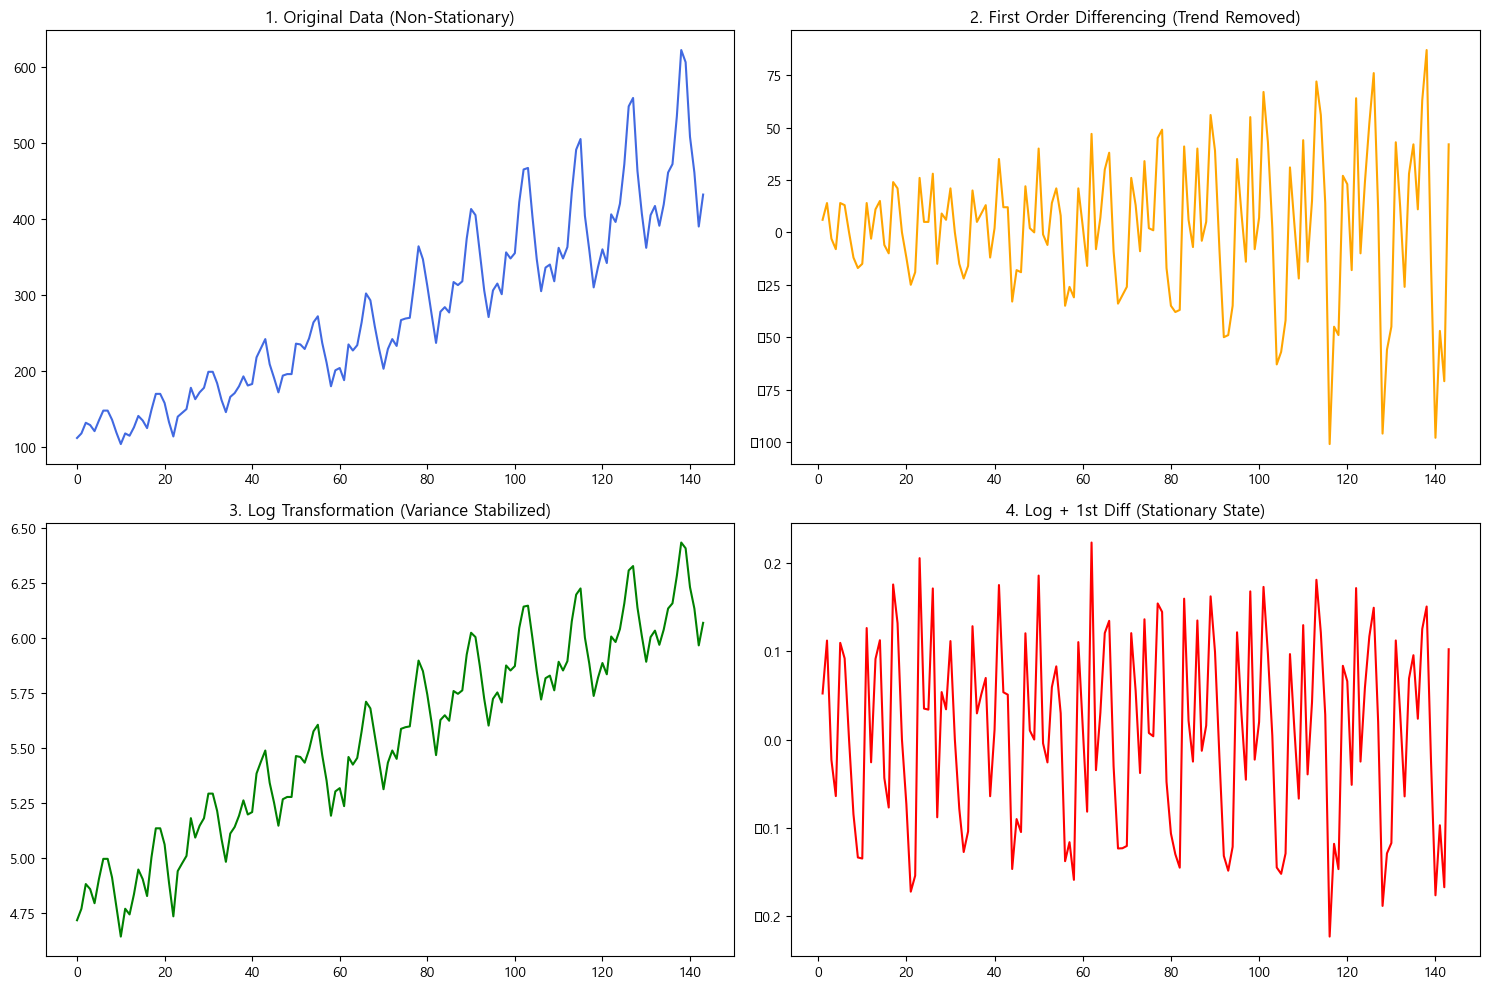

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. 데이터 가공
df['log_cnt'] = np.log(df['cnt'])               # 로그 변환 (진폭 제어)
df['diff_1'] = df['cnt'].diff()                        # 일반 차분 (속도)
df['log_diff_1'] = df['log_cnt'].diff()                # 로그 후 차분 (추세+진폭 제어)
df['seasonal_diff'] = df['log_cnt'].diff(12)           # 계절 차분 (주기성 제거)

# 2. 시각화 (4단 구성)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# [Step 1] 원본 데이터 (비정상성: 우상향 추세 + 커지는 진폭)
axes[0, 0].plot(df['cnt'], color='royalblue')
axes[0, 0].set_title('1. Original Data (Non-Stationary)')

# [Step 2] 1차 차분 (추세는 제거됐으나, 뒤로 갈수록 진폭이 커짐)
axes[0, 1].plot(df['diff_1'], color='orange')
axes[0, 1].set_title('2. First Order Differencing (Trend Removed)')

# [Step 3] 로그 변환 (추세는 남아있으나, 진폭이 일정해짐)
axes[1, 0].plot(df['log_cnt'], color='green')
axes[1, 0].set_title('3. Log Transformation (Variance Stabilized)')

# [Step 4] 로그 변환 후 1차 차분 (최종 정상성 확보 단계)
axes[1, 1].plot(df['log_diff_1'], color='red')
axes[1, 1].set_title('4. Log + 1st Diff (Stationary State)')

plt.tight_layout()
plt.show()

In [36]:
from statsmodels.tsa.stattools import adfuller

# 1차 차분 결과(결측치 제거 후) 검정
result = adfuller(df['seasonal_diff'].dropna())
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: -2.709576818988569
p-value: 0.07239567181769484


In [37]:
# 로그 변환 데이터에 대해 12개월 주기로 계절 차분 수행
seasonal_diff = df['log_cnt'].diff(12).dropna()
result = adfuller(seasonal_diff)
print(f'Seasonal Diff p-value: {result[1]}')

Seasonal Diff p-value: 0.07239567181769484
